**PRÁCTICA RNAP**

**Nombre:** Ronny Oswaldo Guamán Pin

**Carrera**: Ciencias de Datos e Inteligencia Artifical

En la práctica de hoy se implementara:

1.- El perceptrón de Rosenblatt para la compuerta AND.

2.- Una red neuronal multicapa (MLP) para clasificar el dataset Iris.

**PARTE 1: PERCEPTRÓN**

In [41]:
import numpy as np
import matplotlib.pyplot as plt

Función de activacion escalón: Devuelve 1 si es mayor o igual a 0, de caso contrario 0.

In [42]:
def escalon(x):
    return 1 if x >= 0 else 0


Implementar el Perceptrón de Rosenblatt.

Modelo de clasificación binaria que aprende la compuerta lógica AND.

In [43]:
class Perceptron:
    def __init__(self, n_entradas, lr=0.5):
        """
        Inicia los pesos, sesgo y tasa de aprendizaje.
        n_entradas: Número de características de entrada.
        lr: Learning rate (tasa de aprendizaje).
        """
        self.w = np.random.randn(n_entradas) * 0.1
        self.b = 0.0
        self.lr = lr

    def forward(self, x):
        """
        Calcula la salida del perceptrón
        x: Vector de entrada
        return: salida binaria (0 o 1).
        """
        self.x = x
        self.z = np.dot(self.w, x) + self.b
        self.a = escalon(self.z)
        return self.a

    def backward(self, y_real):
        """
        Actualiza los pesos usando la regla de Rosenblatt.
        x: Entrada actual.
        y_real: Valor real esperado.
        return: error de predicción.
        """
        error = y_real - self.a

        #Regla de actualización
        self.w += self.lr * error * self.x
        self.b += self.lr * error

        return error

Dataset de la compuerta AND: Devuelve 1 cuando ambas entradas son 1.

In [44]:
X = np.array([[0,0], [0,1], [1,0], [1,1]])

y = np.array([0,0,0,1])

Entrenamiento del perceptrón.

In [45]:
"""
Se muestra la evolución de los pesos en cada época.
Cuando el error es cero el entrenamiento terminara (convergencia).
"""
perceptron = Perceptron(n_entradas=2, lr=0.5)
for epoca in range(20):
    error_total = 0

    print(f"\n Epoca {epoca}")

    for i in range(len(X)):
        salida = perceptron.forward(X[i])
        error = perceptron.backward(y[i])
        error_total += abs(error)

    print("Pesos:", perceptron.w, "Bias:", perceptron.b)
    print("Error total:", error_total)

    if error_total == 0:
        print("Convergió en la época", epoca)
        break


 Epoca 0
Pesos: [0.41607825 0.46907876] Bias: 0.0
Error total: 2

 Epoca 1
Pesos: [0.41607825 0.46907876] Bias: -0.5
Error total: 1

 Epoca 2
Pesos: [0.41607825 0.46907876] Bias: -0.5
Error total: 0
Convergió en la época 2


Cálculo de la frontera de decisión final.

Representa la recta que separa las clases.

In [46]:
w1, w2 = perceptron.w
b = perceptron.b

print("\nFrontera de decision final:")
print(f"{w1: .3f}*x1 + {w2: .3f}*x2 + {b:.3f} = 0")


Frontera de decision final:
 0.416*x1 +  0.469*x2 + -0.500 = 0


**Gráfico de Perceptron**

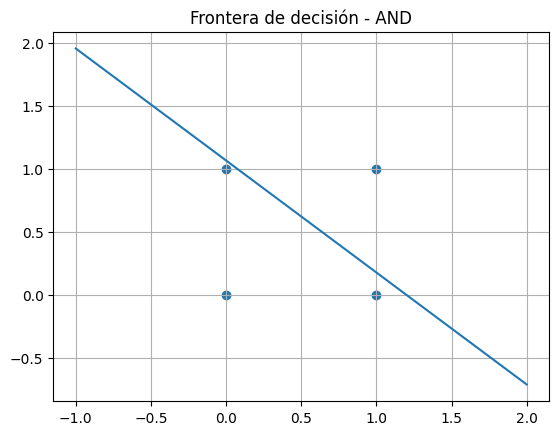

In [47]:
plt.scatter(X[:,0], X[:,1])
x_vals = np.linspace(-1, 2, 100)
y_vals = -(w1 * x_vals + b) / w2
plt.plot(x_vals, y_vals)
plt.title("Frontera de decisión - AND")
plt.grid()
plt.show()


**PARTE 2: MLP**

Carga la dataset Iris y normalización de los datos.
La normalización mejora el rendimiento del modelo.

In [48]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

data = load_iris()
X = data.data
y = data.target
scaler = StandardScaler()
X = scaler.fit_transform(X)

Conversión de etiquetas a formato one-hot para la clasificación multiclase.

In [49]:
def one_hot(y, n_clases):
    return np.eye(n_clases)[y]

y = one_hot(y, 3)

División de datos de entrenamiento y prueba.

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Funciones de activación usadas en la red neuronal.

In [51]:
def relu(x):
    return np.maximum(0, x)

def relu_deriv(x):
    return (x > 0).astype(float)

def softmax(x):
    exp = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp / np.sum(exp, axis=1, keepdims=True)

In [52]:
class MLP:
    """
    Implementación de una Red neuronal Multicapa.
    Usa ReLu en capas ocultas y softmax en la salida.
    """
    def __init__(self, n_capas, lr=0.01):
        """
        Inicia la red
        n_capas: Lista con neuronas por capa.
        lr: Learning rate.
        """
        self.lr = lr
        self.W = []
        self.b = []
        self.losses = []
        for i in range(len(n_capas) - 1):
            w = np.random.randn(n_capas[i], n_capas[i + 1]) * 0.1
            b = np.zeros((1 , n_capas[i + 1]))
            self.W.append(w)
            self.b.append(b)

    def forward(self, X):
        """
        Propagación hacia adelante
        """
        self.A = [X]
        self.Z = []
        entrada = X
        for i in range(len(self.W)):
            z = np.dot(entrada, self.W[i]) + self.b[i]

            if i == len(self.W) - 1:
                a = softmax(z)
            else:
                a = relu(z)

            self.Z.append(z)
            self.A.append(a)
            entrada = a
        return entrada

    def backward(self, y_real):
        """
        Backpropagation para ajustar pesos
        """
        m = y_real.shape[0]
        delta = (self.A[-1] - y_real)

        for i in range(len(self.W) -1, -1, -1):
            dW = np.dot(self.A[i].T, delta) / m
            db = np.sum(delta, axis = 0, keepdims = True) / m
            if i > 0:
                delta = np.dot(delta, self.W[i].T) * relu_deriv(self.Z[i-1])
            self.W[i] -= self.lr * dW
            self.b[i] -= self.lr * db

    def entrenamiento(self, X, y, epocas= 1000):
        """
        Entrenamiento del modelo, guarda el loss en entrenamiento
        """
        for ep in range(epocas):
            salida = self.forward(X)
            self.backward(y)
            loss = -np.mean(np.sum(y * np.log(salida + 1e-8), axis=1))
            self.losses.append(loss)

            if ep % 200 == 0:
              loss = -np.mean(np.sum(y * np.log(salida + 1e-8), axis=1))
              print("Epoca", ep)
              print("Loss", loss)

    def predecir(self, X):
        """
        Devuelve la clase predicha
        """
        return np.argmax(self.forward(X), axis=1)



Entrenamiento del modelo MLP

In [53]:
np.random.seed(42)
red = MLP(n_capas = [4,8,3], lr = 0.01)
red.entrenamiento(X_train, y_train, epocas = 1000)

Epoca 0
Loss 1.1062293504814813
Epoca 200
Loss 1.066291430541151
Epoca 400
Loss 0.8844495932406263
Epoca 600
Loss 0.602493482738911
Epoca 800
Loss 0.47523575419571984


**Gráfico del Loss**

Se grafica la función de pérdida (loss) para observar el aprendizaje del modelo.

Se espera que el valor disminuya con las épocas, indicando que la red mejora su rendimiento.

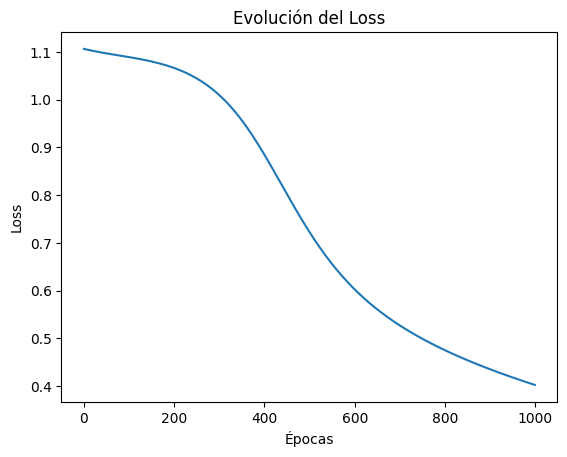

In [54]:
plt.plot(red.losses)
plt.title("Evolución del Loss")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.show()

Evaluación del modelo usando accuracy

In [55]:
y_pred = red.predecir(X_test)
y_real = np.argmax(y_test, axis=1)

accuracy = np.mean(y_pred == y_real)
print("Accuracy:", accuracy)

Accuracy: 0.8666666666666667


In [56]:
print(classification_report(y_real, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.56      0.71         9
           2       0.73      1.00      0.85        11

    accuracy                           0.87        30
   macro avg       0.91      0.85      0.85        30
weighted avg       0.90      0.87      0.86        30

